# Laboratorio 2: Agrupacion

Este es el diccionario proporcionado por Senecafé sobre los datos que debemos analizar para cumplir con la tarea propuesta.

| ATRIBUTO | DEFINICIÓN |
| :- | :- |
| **ID** | Código único generado para cada grano de café inspeccionado.  |
| **Área** | Superficie ocupada por el grano, medida como el número total de píxeles dentro de sus límites. Indica el tamaño del grano. |
| **Perímetro** | Longitud de la frontera del grano, equivalente a su circunferencia. Refleja la complejidad y continuidad del borde. |
| **LongitudEjeMayor** | Distancia entre los extremos de la línea más larga que puede trazarse a lo largo del grano. Representa la longitud máxima del grano. |
| **LongitudEjeMenor** | Longitud de la línea más larga que puede trazarse perpendicular al eje mayor. Refleja el ancho máximo transversal del grano. |
| **RelaciónAspecto** | Relación entre la longitud del eje mayor y la del eje menor. Indica si el grano es Alargado (> 1.3) o Redondeado (≤ 1.3).  |
| **Excentricidad** | Medida de la desviación de la forma respecto a un círculo, basada en la elipse equivalente. Valores cercanos a 0 indican formas circulares; cercanos a 1, formas alargadas. |
| **ÁreaConvexa** | Número de píxeles contenidos en el polígono convexo más pequeño que abarca el grano. Permite identificar irregularidades en el borde. |
| **DiámetroEquivalente** | Diámetro de un círculo con el mismo área que el grano. Facilita la comparación entre granos de distintas formas mediante una medida circular equivalente. |
| **Medida** | Proporción entre el área del grano y el área de su caja delimitadora (bounding box). Evalúa qué tan bien el grano ocupa su espacio mínimo rectangular. |
| **Solidez** | Proporción entre el área del grano y el área de su envolvente convexa. Indica la regularidad de la forma. |
| **Redondez** | Medida calculada con la fórmula (4πA) / P^2. Indica circularidad. Valores cercanos a 1 indican formas circulares; valores bajos, irregularidad o elongación. |
| **Compacidad** | Índice alternativo de redondez: relación entre el diámetro y el eje mayor. Valores altos reflejan granos más compactos y redondeados. |
| **FactorForma1** | Medida geométrica derivada que combina variables básicas para caracterizar la morfología. Ayuda a diferenciar variedades mediante combinaciones de atributos básicos. |
| **FactorForma2** | Medida complementaria de la geometría que captura diferencias sutiles en contorno y proporciones. Permite distinguir granos con diferencias sutiles en proporciones o contorno. |
| **FactorForma3** | Indicador de forma basado en combinaciones no lineales de métricas principales. Aporta información adicional para la separación entre variedades. |
| **FactorForma4** | Medida adicional que sintetiza características geométricas avanzadas. Fortalece la capacidad de clasificación en contextos complejos. |
| **DefectoVisible** | Permite diferenciar entre granos sanos normales y granos con defectos visibles (Normal, Defectuoso) |
| **MétodoSecado** | Método de procesamiento postcosecha. Refleja una categoría relevante en el dominio cafetero, usada en caracterización de calidad y perfiles de taza (Natural, Lavado, Honey) |


## 0. Instalación e importación de librerías

In [1]:
import pandas as pd
import numpy as np
import sys
import os
import os.path as osp
import joblib

from sklearn.preprocessing import RobustScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA, IncrementalPCA
from sklearn.metrics import silhouette_score, silhouette_samples, rand_score

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

## 1. Introducción a los datos

**Carga de los datos**

In [2]:
data = pd.read_csv('Datos_SenecafeAlpes.csv', sep=';')
data.head(10)

,ID,Area,Perimetro,LongitudEjeMayor,LongitudEjeMenor,RelacionAspecto,Excentricidad,AreaConvexa,DiametroEquivalente,Medida,Solidez,Redondez,Compacidad,FactorForma1,FactorForma2,FactorForma3,FactorForma4,DefectoVisible,MétodoSecado
0,G006149,50836,923618.0,358.515147,181.388899,alargado,NaN,NaN,254.413847,0.804762,0.983840,0.748853,0.709632,0.007052,0.001103,0.503578,0.995321,Normal,Lavado
1,G007234,62764,1003767.0,409.207082,198.330199,Alargado,NaN,64158.0,282.689948,0.703995,0.978272,0.782807,0.690824,0.006520,0.000916,0.477237,0.984666,NaN,Natural
2,G007054,59965,994266.0,389.088529,197.967275,Alargado,0.860886,60910.0,276.314692,0.661581,0.984485,0.762259,0.710159,0.006489,0.001018,0.504326,0.991211,Normal,Natural
3,G006619,55035,917.6,379.346822,185.390577,Alargado,0.872446,55591.0,NaN,0.799695,0.989998,0.821376,0.697811,0.006893,0.001008,0.486941,0.996380,Normal,Lavado
4,G013353,39324,737773.0,262.520242,191.176858,Alargado,0.685326,39758.0,223.760747,0.775392,0.989084,0.907867,0.852356,0.006676,0.002174,0.726511,0.997630,Normal,Lavado
5,G006127,50654,879938.0,357.233899,181.407743,Alargado,0.861468,51251.0,253.958020,0.634857,0.988351,0.822090,0.710901,0.007052,0.001111,NaN,0.995211,NaN,Natural
6,G008237,42293,775769.0,290.699462,185.793277,Alargado,0.769103,42758.0,232.054132,0.715049,0.989125,NaN,0.798261,0.006873,0.001722,0.637221,0.997021,Normal,Natural
7,G005406,91401,1160437.0,458.039639,256.217667,Alargado,0.828912,NaN,341.138341,0.809604,0.992109,0.852938,0.744779,0.005011,0.000951,0.554696,0.991628,Normal,Lavado
8,G000477,36169,685632.0,238.456574,193.313785,Redondeado,0.585479,NaN,214.596834,0.791513,0.992236,NaN,0.899941,0.006593,0.002668,0.809894,0.999021,normal,lavado
9,G008425,43156,780507.0,289.280289,190.945723,Alargado,NaN,43845.0,234.409739,0.755294,0.984286,0.890220,0.810320,0.006703,NaN,0.656619,0.994770,Normal,NaN


In [3]:
data.shape

(14291, 19)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14291 entries, 0 to 14290
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   14291 non-null  object 
 1   Area                 14291 non-null  int64  
 2   Perimetro            13054 non-null  float64
 3   LongitudEjeMayor     13890 non-null  float64
 4   LongitudEjeMenor     14291 non-null  float64
 5   RelacionAspecto      13825 non-null  object 
 6   Excentricidad        13687 non-null  float64
 7   AreaConvexa          12868 non-null  float64
 8   DiametroEquivalente  12368 non-null  float64
 9   Medida               14291 non-null  float64
 10  Solidez              11985 non-null  float64
 11  Redondez             12228 non-null  float64
 12  Compacidad           13641 non-null  float64
 13  FactorForma1         13172 non-null  float64
 14  FactorForma2         13185 non-null  float64
 15  FactorForma3         13813 non-null 

\
En primer lugar eliminamos la columna ID, debido a que no tiene información que sea importante para nosotros.

In [5]:
data.drop('ID', axis=1, inplace=True)

\
**Nulos:** Ahora manejamos los nulos, debido a que son muchos.

In [6]:
data.isna().sum()

Area                      0
Perimetro              1237
LongitudEjeMayor        401
LongitudEjeMenor          0
RelacionAspecto         466
Excentricidad           604
AreaConvexa            1423
DiametroEquivalente    1923
Medida                    0
Solidez                2306
Redondez               2063
Compacidad              650
FactorForma1           1119
FactorForma2           1106
FactorForma3            478
FactorForma4           1159
DefectoVisible         2935
MétodoSecado            587
dtype: int64

In [7]:
(data.isnull().sum() / len(data)) * 100

Area                    0.000000
Perimetro               8.655797
LongitudEjeMayor        2.805962
LongitudEjeMenor        0.000000
RelacionAspecto         3.260794
Excentricidad           4.226436
AreaConvexa             9.957316
DiametroEquivalente    13.456021
Medida                  0.000000
Solidez                16.136030
Redondez               14.435659
Compacidad              4.548317
FactorForma1            7.830103
FactorForma2            7.739137
FactorForma3            3.344762
FactorForma4            8.109999
DefectoVisible         20.537401
MétodoSecado            4.107480
dtype: float64

\
En este caso todas las columnas tienen un porcentaje inferior al 40% de nulos, y aparte todas las columnas son informativas, entonces con el fin de no perder registros lo que se hará es imputar las numéricas con la mediana que es resistente a outliers y crear una categoría "desconocido" para las categóricas

In [8]:
# Rellenar numéricas con la mediana
for col in data.select_dtypes(include="number"):
    data[col] = data[col].fillna(data[col].median())

# Rellenar categóricas con "Desconocido"
for col in data.select_dtypes("object"):
    data[col] = data[col].fillna("Desconocido")

In [9]:
data.isna().sum()

Area                   0
Perimetro              0
LongitudEjeMayor       0
LongitudEjeMenor       0
RelacionAspecto        0
Excentricidad          0
AreaConvexa            0
DiametroEquivalente    0
Medida                 0
Solidez                0
Redondez               0
Compacidad             0
FactorForma1           0
FactorForma2           0
FactorForma3           0
FactorForma4           0
DefectoVisible         0
MétodoSecado           0
dtype: int64

\
**Duplicados:**

Se debn eliminar los duplicados debido a que pueden sesgar las distancias de nuestros centroides.

In [10]:
# Verificamos si hay duplicados
print(f'Duplicados: {data.duplicated().sum()}')

Duplicados: 462


In [11]:
data = data.drop_duplicates()

In [12]:
data.shape

(13829, 18)

**Limpieza:**

In [13]:
data.describe()

,Area,Perimetro,LongitudEjeMayor,LongitudEjeMenor,Excentricidad,AreaConvexa,DiametroEquivalente,Medida,Solidez,Redondez,Compacidad,FactorForma1,FactorForma2,FactorForma3,FactorForma4
count,13829.000000,1.382900e+04,13829.000000,13829.000000,13829.000000,13829.000000,13829.000000,13829.000000,13829.000000,13829.000000,13829.000000,13829.000000,13829.000000,13829.000000,13829.000000
mean,52987.819148,7.718350e+05,319.116768,202.087990,0.750521,52681.917456,250.947295,0.749697,0.987004,0.874556,0.799394,0.006568,0.001711,0.643222,0.994443
std,29290.519559,3.123223e+05,85.026610,45.381468,0.097511,28076.643284,56.430623,0.050768,0.024149,0.058747,0.066196,0.001118,0.000577,0.099072,0.038079
min,-62716.000000,-1.012143e+06,-421.444657,-200.838672,-0.835004,-78423.000000,-448.402605,-0.798706,-0.989042,-0.896861,-0.843901,-0.007982,-0.002673,-0.683269,-0.998527
25%,36340.000000,6.855180e+05,254.082944,175.842829,0.718731,37713.000000,219.149710,0.718669,0.986329,0.843459,0.764782,0.006013,0.001189,0.583864,0.994020
50%,44642.000000,7.720345e+05,296.682345,192.411751,0.764392,45107.500000,238.579492,0.759942,0.988279,0.883353,0.800994,0.006645,0.001691,0.641648,0.996377
75%,61261.000000,9.315770e+05,374.486202,216.805272,0.807969,58970.000000,269.890276,0.786893,0.989643,0.911681,0.832231,0.007204,0.002125,0.693615,0.997759
max,254616.000000,1.921685e+06,738.860154,460.198497,0.911423,251082.000000,569.374358,0.866195,0.994378,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [14]:
data = data[
    (data['Area'] > 0) &
    (data['Perimetro'] > 0) &
    (data['LongitudEjeMayor'] > 0) &
    (data['LongitudEjeMenor'] > 0) &
    (data['Excentricidad'] > 0) &
    (data['AreaConvexa'] > 0) &
    (data['DiametroEquivalente'] > 0) &
    (data['Medida'] > 0) &
    (data['Medida'] > 0) &
    (data['Solidez'] > 0) &
    (data['Redondez'] > 0) &
    (data['Compacidad'] > 0) &
    (data['FactorForma1'] > 0) &
    (data['FactorForma2'] > 0) &
    (data['FactorForma3'] > 0) &
    (data['FactorForma4'] > 0)
]

In [15]:
data.describe()

,Area,Perimetro,LongitudEjeMayor,LongitudEjeMenor,Excentricidad,AreaConvexa,DiametroEquivalente,Medida,Solidez,Redondez,Compacidad,FactorForma1,FactorForma2,FactorForma3,FactorForma4
count,13761.000000,1.376100e+04,13761.000000,13761.000000,13761.000000,13761.000000,13761.000000,13761.000000,13761.000000,13761.000000,13761.000000,13761.000000,13761.000000,13761.000000,13761.000000
mean,53009.378679,7.725878e+05,319.257053,202.207253,0.751425,52728.082007,251.232781,0.749810,0.987292,0.874805,0.799882,0.006574,0.001713,0.643538,0.995166
std,29272.445847,3.105534e+05,84.457874,44.893048,0.089982,27992.681664,55.227447,0.049042,0.004328,0.055045,0.060444,0.001083,0.000572,0.097332,0.004199
min,20420.000000,5.536000e+02,183.601165,122.512653,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.416499,0.947687
25%,36346.000000,6.856370e+05,254.099314,175.855016,0.718804,37731.000000,219.216514,0.718701,0.986330,0.843559,0.764921,0.006015,0.001190,0.584032,0.994025
50%,44634.000000,7.720345e+05,296.682345,192.419462,0.764392,45107.500000,238.579492,0.759942,0.988279,0.883353,0.800994,0.006645,0.001691,0.641648,0.996377
75%,61251.000000,9.317240e+05,374.486202,216.796005,0.807969,58957.000000,269.909146,0.786893,0.989644,0.911668,0.832272,0.007204,0.002125,0.693660,0.997761
max,254616.000000,1.921685e+06,738.860154,460.198497,0.911423,251082.000000,569.374358,0.866195,0.994378,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


\
**Variables categóricas:**

Ahora convertiremos las variables categóricas a númericas para poder usar nuestro algoritmo. Se usará one-hot y se revisarán las categorías antes para corregir errores.

In [16]:
data.head(3)

,Area,Perimetro,LongitudEjeMayor,LongitudEjeMenor,RelacionAspecto,Excentricidad,AreaConvexa,DiametroEquivalente,Medida,Solidez,Redondez,Compacidad,FactorForma1,FactorForma2,FactorForma3,FactorForma4,DefectoVisible,MétodoSecado
0,50836,923618.0,358.515147,181.388899,alargado,0.764392,45107.5,254.413847,0.804762,0.983840,0.748853,0.709632,0.007052,0.001103,0.503578,0.995321,Normal,Lavado
1,62764,1003767.0,409.207082,198.330199,Alargado,0.764392,64158.0,282.689948,0.703995,0.978272,0.782807,0.690824,0.006520,0.000916,0.477237,0.984666,Desconocido,Natural
2,59965,994266.0,389.088529,197.967275,Alargado,0.860886,60910.0,276.314692,0.661581,0.984485,0.762259,0.710159,0.006489,0.001018,0.504326,0.991211,Normal,Natural


In [17]:
data['RelacionAspecto'].value_counts()

RelacionAspecto
Alargado       11602
Redondeado      1674
Desconocido      446
alargado          29
redondeado        10
Name: count, dtype: int64

In [18]:
# Se reemplazan las categorías mal escritas por su forma correcta.
data['RelacionAspecto'] = data["RelacionAspecto"].str.capitalize()
data['RelacionAspecto'].value_counts()

RelacionAspecto
Alargado       11631
Redondeado      1684
Desconocido      446
Name: count, dtype: int64

In [19]:
data["DefectoVisible"].value_counts()

DefectoVisible
Normal         8704
Desconocido    2823
normal         2234
Name: count, dtype: int64

In [20]:
data["DefectoVisible"] = data["DefectoVisible"].str.capitalize()
data["DefectoVisible"].value_counts()

DefectoVisible
Normal         10938
Desconocido     2823
Name: count, dtype: int64

In [21]:
data["MétodoSecado"].value_counts()

MétodoSecado
Lavado         5964
Natural        4473
lavado         1532
natural        1160
Desconocido     557
Honey            62
honey            13
Name: count, dtype: int64

In [22]:
data["MétodoSecado"] = data["MétodoSecado"].str.capitalize()
data["MétodoSecado"].value_counts()

MétodoSecado
Lavado         7496
Natural        5633
Desconocido     557
Honey            75
Name: count, dtype: int64

In [23]:
data = pd.get_dummies(
    data,
    columns=["DefectoVisible", "MétodoSecado", "RelacionAspecto"],  
)

In [24]:
data.sample(3)

,Area,Perimetro,LongitudEjeMayor,LongitudEjeMenor,Excentricidad,AreaConvexa,DiametroEquivalente,Medida,Solidez,Redondez,...,FactorForma4,DefectoVisible_Desconocido,DefectoVisible_Normal,MétodoSecado_Desconocido,MétodoSecado_Honey,MétodoSecado_Lavado,MétodoSecado_Natural,RelacionAspecto_Alargado,RelacionAspecto_Desconocido,RelacionAspecto_Redondeado
5840,33429,772034.5,229.446090,185.698093,0.587351,45107.5,206.308324,0.791744,0.991576,0.968463,...,0.998954,False,True,False,False,True,False,False,False,True
8183,80170,772034.5,296.682345,247.792784,0.803328,81325.0,319.492745,0.758992,0.988279,0.865546,...,0.990042,True,False,False,False,True,False,True,False,False
6023,52856,915191.0,380.015728,177.642170,0.764392,53359.0,259.419254,0.809483,0.990573,0.793014,...,0.996912,True,False,False,False,True,False,True,False,False


\
**Outliers:**

In [25]:
# Se calcula el rango intercuartil y se determinan los outliers por variable
numeric_data = data.select_dtypes(include=["number"])

Q1 = numeric_data.quantile(0.25)
Q3 = numeric_data.quantile(0.75)
IQR = Q3 - Q1
outliers = ((numeric_data < (Q1 - 1.5 * IQR)) | (numeric_data > (Q3 + 1.5 * IQR)))
total = outliers.sum()
print(total)

# Número de datos con outliers
datos_outliers = outliers.any(axis=1).sum()
print(f"Número de datos con outliers: {datos_outliers}")

Area                    554
Perimetro              1662
LongitudEjeMayor        385
LongitudEjeMenor        572
Excentricidad           957
AreaConvexa             610
DiametroEquivalente     523
Medida                  276
Solidez                1081
Redondez                209
Compacidad              224
FactorForma1            570
FactorForma2              3
FactorForma3            266
FactorForma4            880
dtype: int64
Número de datos con outliers: 4297


Debido a que el objetivo es distinguir entre granos defectuosos o normales, es posible que los outliers no sean errores en los datos sino nos muestren algo importante de nuestro dataset. Por este motivo, no se eliminarán

\
**Estandarización:**

In [26]:
from sklearn.preprocessing import RobustScaler

# 1. Crear el objeto escalador
robust_scaler = RobustScaler()

# 2. Ajustar a los datos y transformar
scaled_data = robust_scaler.fit_transform(data)

# 3. Volver a DataFrame
scaled_df = pd.DataFrame(scaled_data, columns=data.columns)

scaled_df # IMPORTANTE: Este será el dataset para los modelos que usemos

,Area,Perimetro,LongitudEjeMayor,LongitudEjeMenor,Excentricidad,AreaConvexa,DiametroEquivalente,Medida,Solidez,Redondez,...,FactorForma4,DefectoVisible_Desconocido,DefectoVisible_Normal,MétodoSecado_Desconocido,MétodoSecado_Honey,MétodoSecado_Lavado,MétodoSecado_Natural,RelacionAspecto_Alargado,RelacionAspecto_Desconocido,RelacionAspecto_Redondeado
0,0.249026,0.615975,0.513617,-0.269426,0.000000,0.000000,0.312360,0.657254,-1.339494,-1.974770,...,-0.282643,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.727966,0.941669,0.934693,0.144372,0.000000,0.897508,0.870155,-0.820432,-3.019754,-1.476247,...,-3.135090,1.0,-1.0,0.0,0.0,-1.0,1.0,0.0,0.0,0.0
2,0.615579,0.903061,0.767577,0.135508,1.082188,0.744488,0.744392,-1.442422,-1.144767,-1.777938,...,-1.382917,0.0,0.0,0.0,0.0,-1.0,1.0,0.0,0.0,0.0
3,0.417627,-3.133513,0.686657,-0.171683,1.211835,0.493899,0.000000,0.582950,0.519016,-0.909966,...,0.000767,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.213210,-0.139225,-0.283769,-0.030351,-0.886735,-0.252026,-0.292325,0.226560,0.243053,0.359911,...,0.335510,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13756,1.551174,1.404965,1.260863,1.107146,0.936766,1.833718,1.716697,0.546931,0.793531,-0.673749,...,-0.551016,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13757,-0.191809,-0.067629,-0.108473,-0.317251,0.112780,-0.225078,-0.262512,-0.994078,-0.002059,-0.082302,...,0.215852,0.0,0.0,0.0,0.0,-1.0,1.0,0.0,0.0,0.0
13758,1.821723,1.562718,1.330328,1.463914,0.775984,2.152195,0.000000,0.351894,0.924703,-0.555987,...,-0.626871,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13759,-0.249267,-0.246346,-0.415209,0.149881,-1.916934,-0.297206,-0.343016,-0.115087,0.636100,1.038682,...,0.655429,1.0,-1.0,1.0,0.0,-1.0,0.0,-1.0,0.0,1.0


In [27]:
# Guardamos el scaler por si necesitamos usarlo más adelante.
joblib.dump(robust_scaler, 'robust_scaler.joblib')

['robust_scaler.joblib']

## 1. Modelamiento

### K means

Como primer paso se crea un diccionario probando diferentes combinaciones entre semilla y k (número de grupos) en donde cada semilla tiene asociada una lista con los diferentes scores de las diferentes ks. No obstante no basta con minimizar el score puesto que este siempre disminuye al aumetar el k (debido a que la suma de distancias disminuye con menos puntos por grupo), por lo que se debe usar el método del codo para determinar el k.

In [28]:
def buscar_modelo(k, semilla):
    print(f"Entrenando el modelo con k={k} y semilla={semilla}.")
    model = KMeans(n_clusters=k,random_state=semilla, init='random', n_init=1)
    model.fit(data)

    return model.inertia_

In [29]:
candidatos = [9,22,33,42,50]
grupos = range(2,10)
distorsions = dict()

for semilla in candidatos:
    distorsions[semilla] = list()
    for k in grupos:
        inertia = buscar_modelo(k, semilla)
        distorsions[semilla].append(inertia)
        print("Score:",inertia)
        print('-'*50)

Entrenando el modelo con k=2 y semilla=9.
Score: 784785461262747.8
--------------------------------------------------
Entrenando el modelo con k=3 y semilla=9.
Score: 212446696552841.47
--------------------------------------------------
Entrenando el modelo con k=4 y semilla=9.
Score: 81512790076311.03
--------------------------------------------------
Entrenando el modelo con k=5 y semilla=9.
Score: 48685569954601.336
--------------------------------------------------
Entrenando el modelo con k=6 y semilla=9.
Score: 32787470709667.113
--------------------------------------------------
Entrenando el modelo con k=7 y semilla=9.
Score: 27178813958207.707
--------------------------------------------------
Entrenando el modelo con k=8 y semilla=9.
Score: 21841914457911.887
--------------------------------------------------
Entrenando el modelo con k=9 y semilla=9.
Score: 20223615017211.664
--------------------------------------------------
Entrenando el modelo con k=2 y semilla=22.
Score: 

**Método del codo: Búsqueda de hiperparámetros**

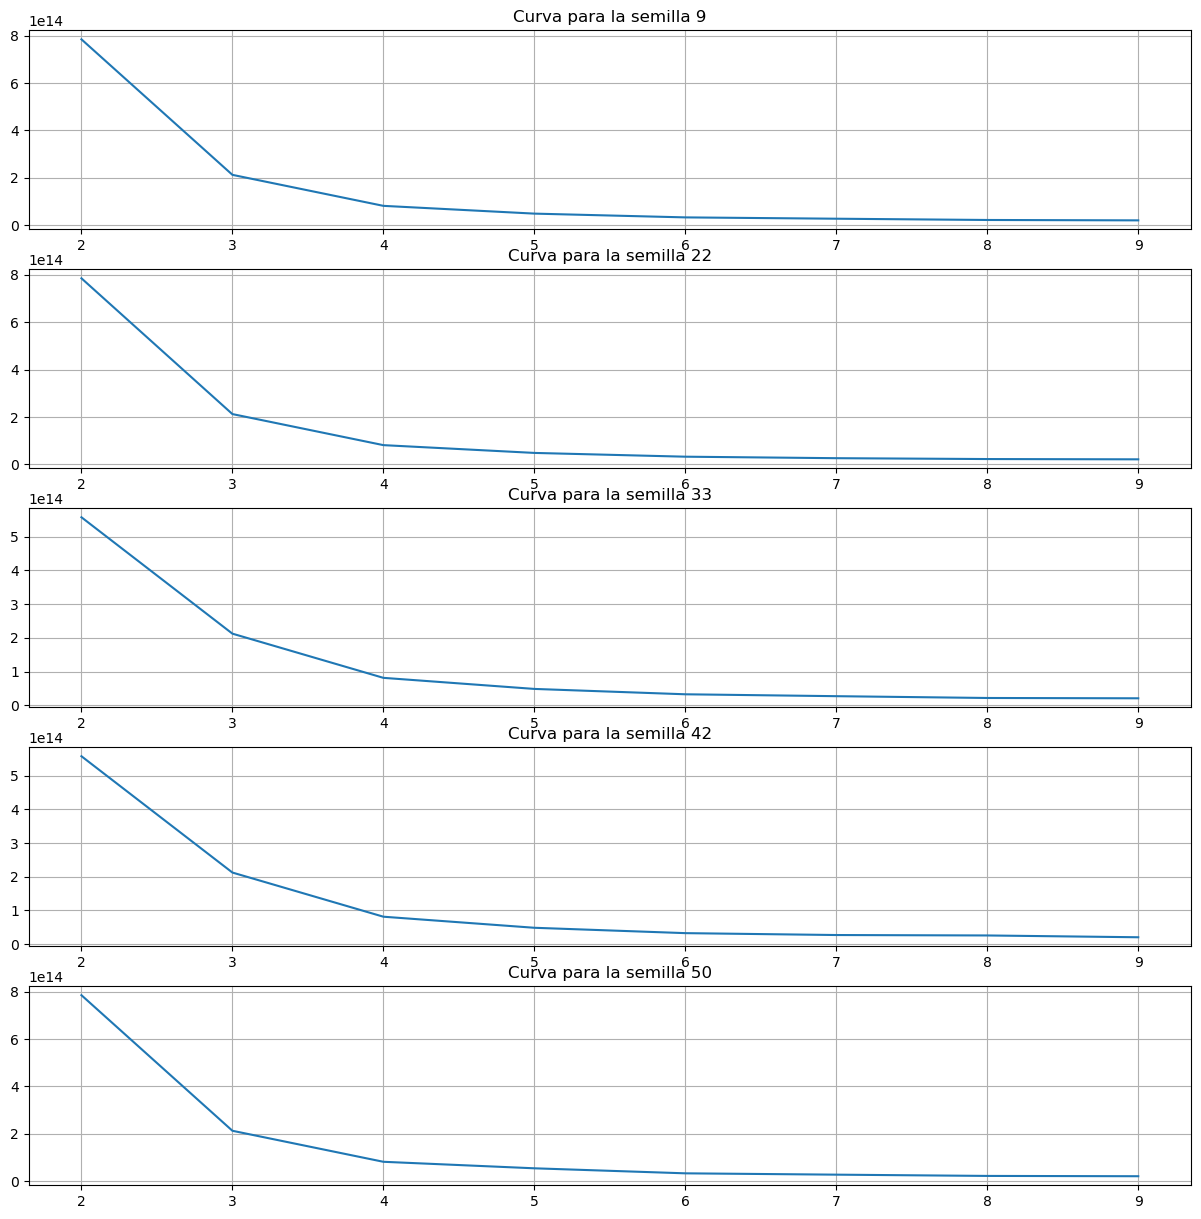

In [30]:
fig = plt.figure(figsize=(15, 15))

for i, sem in enumerate(candidatos):
    ax = plt.subplot(len(candidatos), 1, i + 1)
    plt.plot(grupos, distorsions[sem])
    plt.grid(True)
    plt.title(f'Curva para la semilla {sem}')
plt.show()

En este caso podemos ver que nuestro k puede ser 3 o 4, sin embargo, hay una caida importante de la inercia entre 3 y 4 por lo que sería más conveniente elegir 4 clusters, sin embargo, vamos a verificar usando el método de silueta.

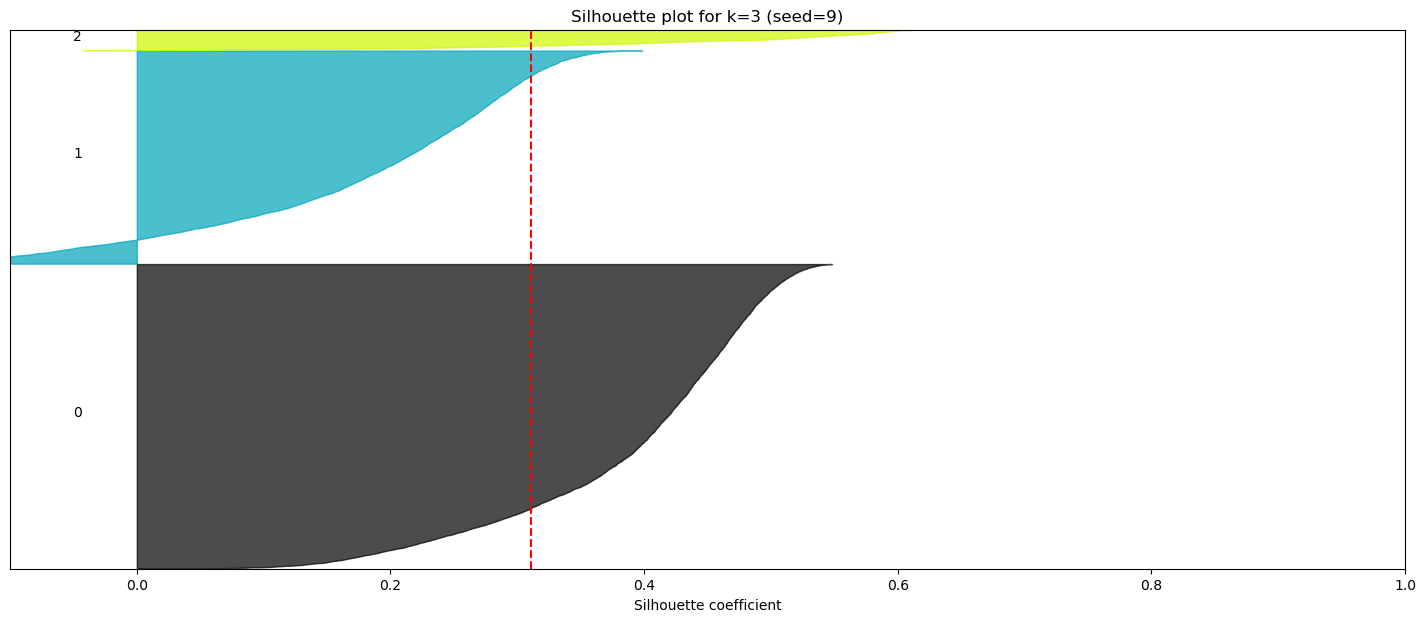

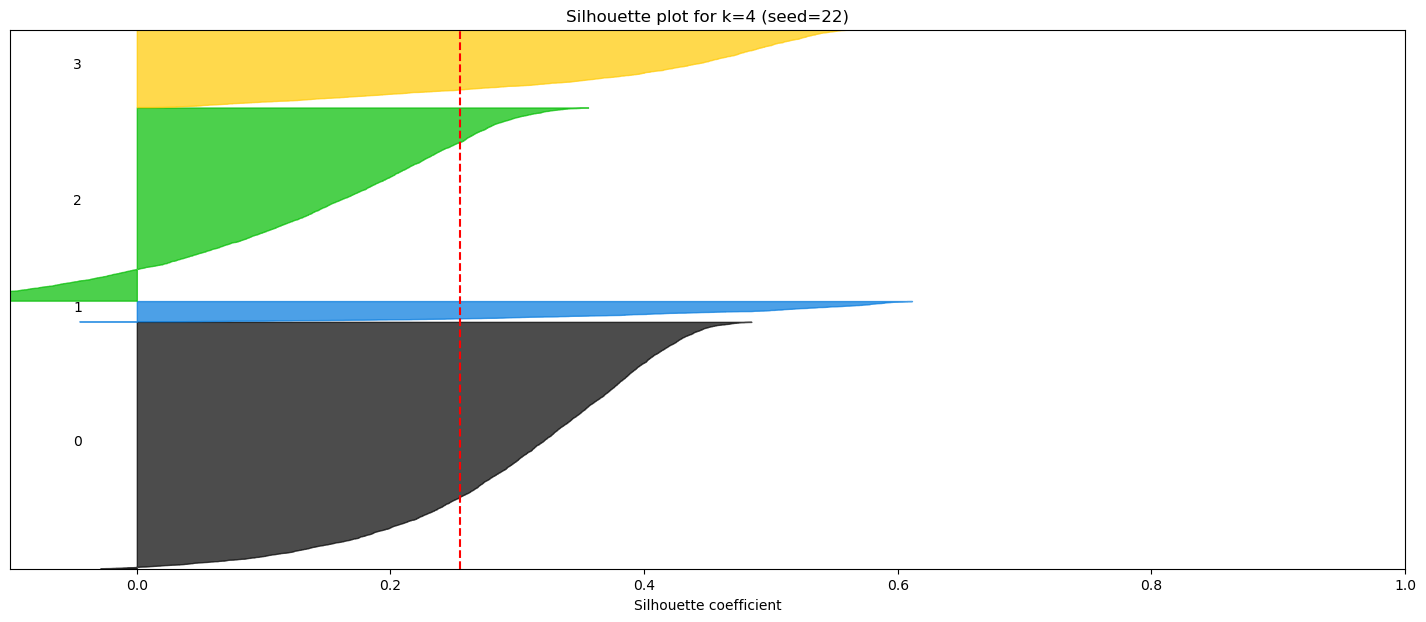

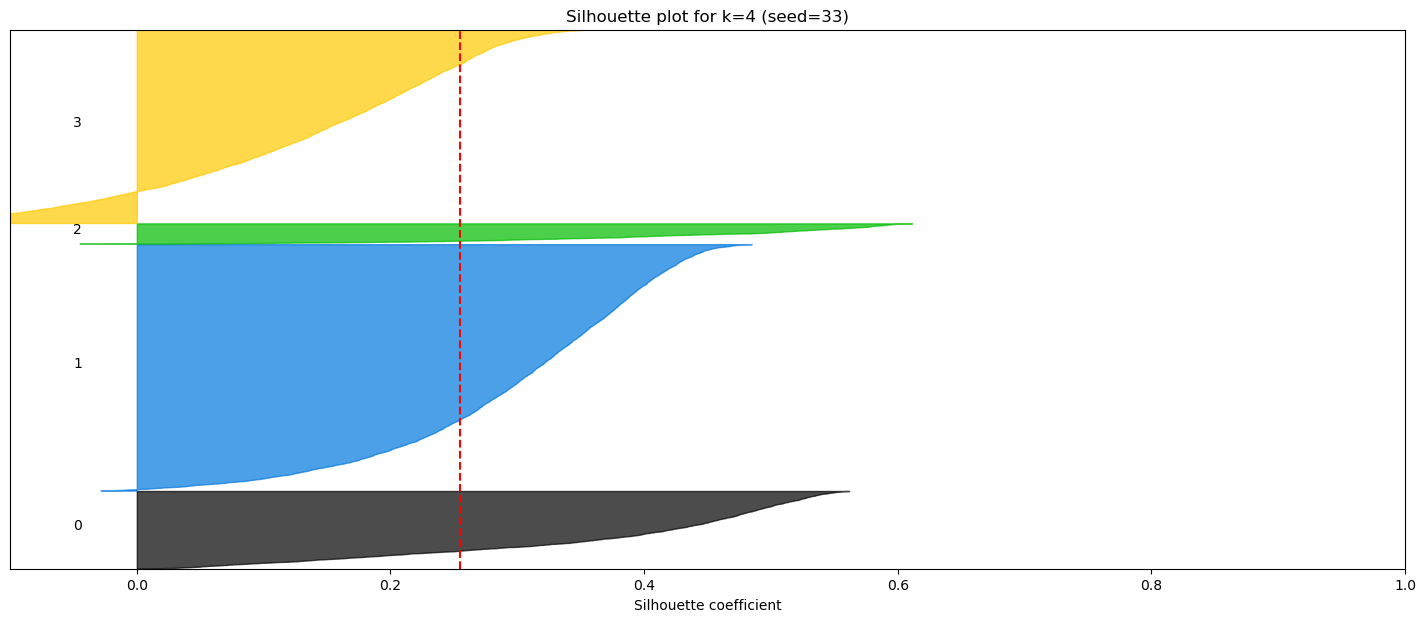

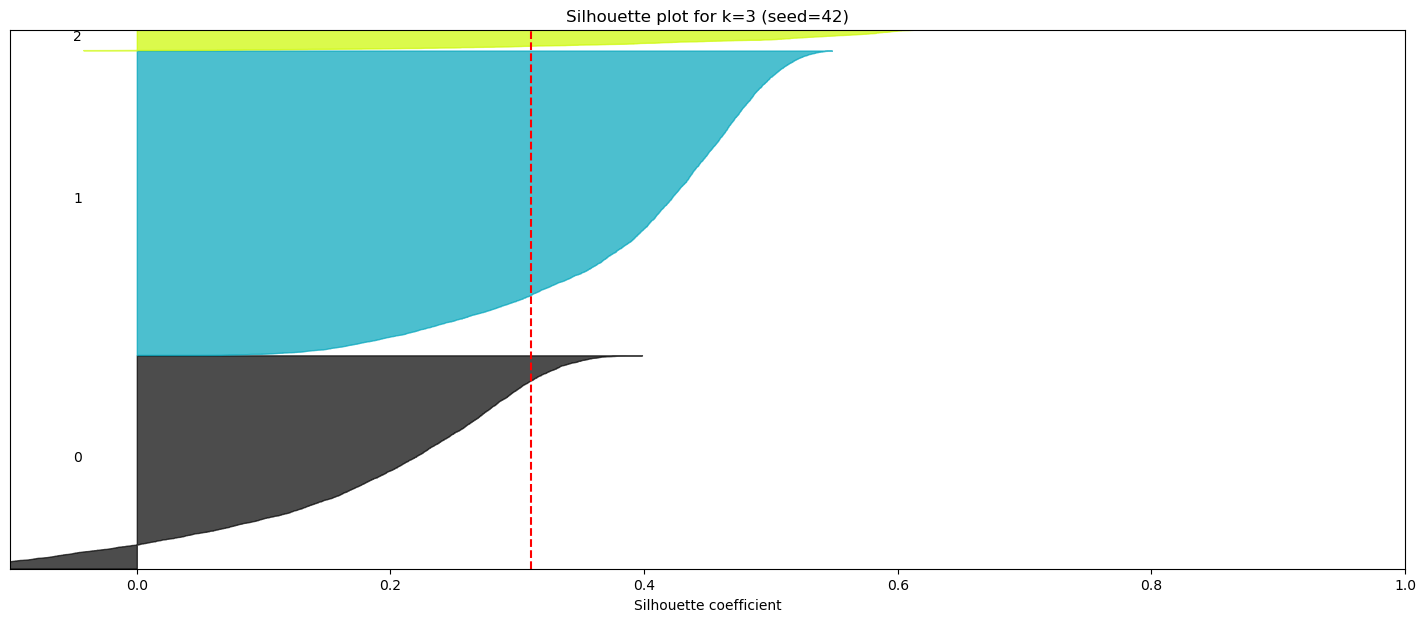

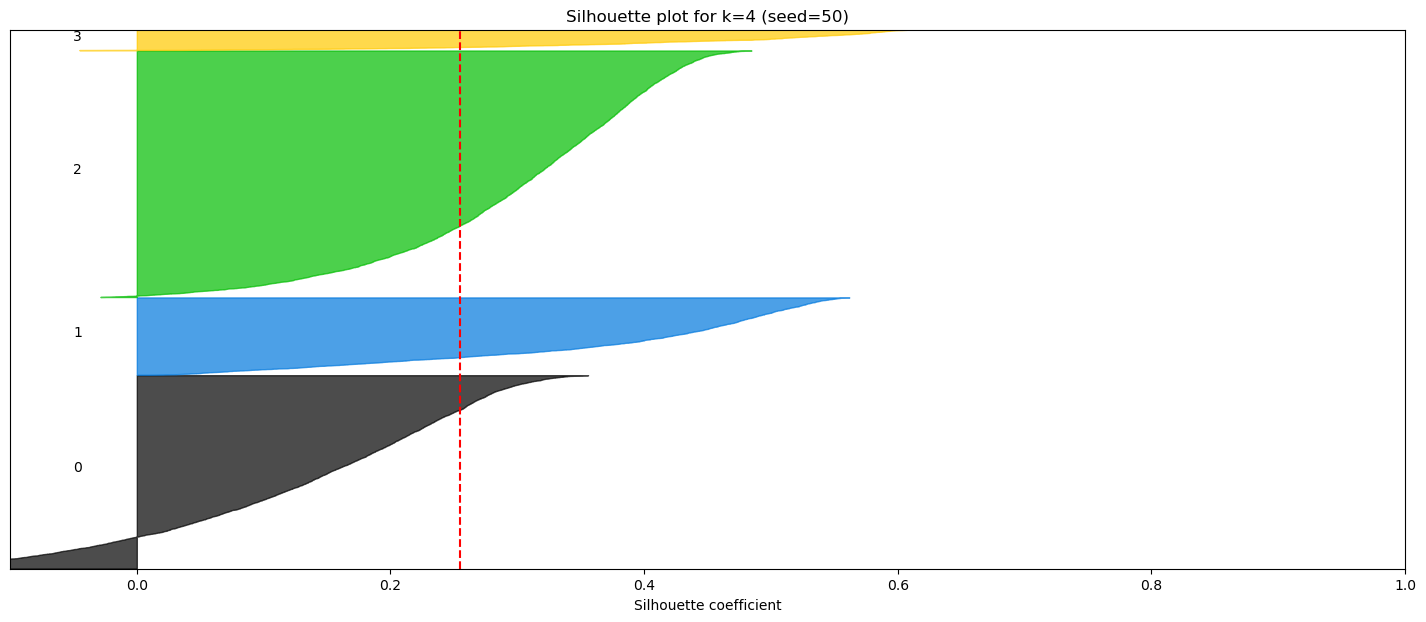

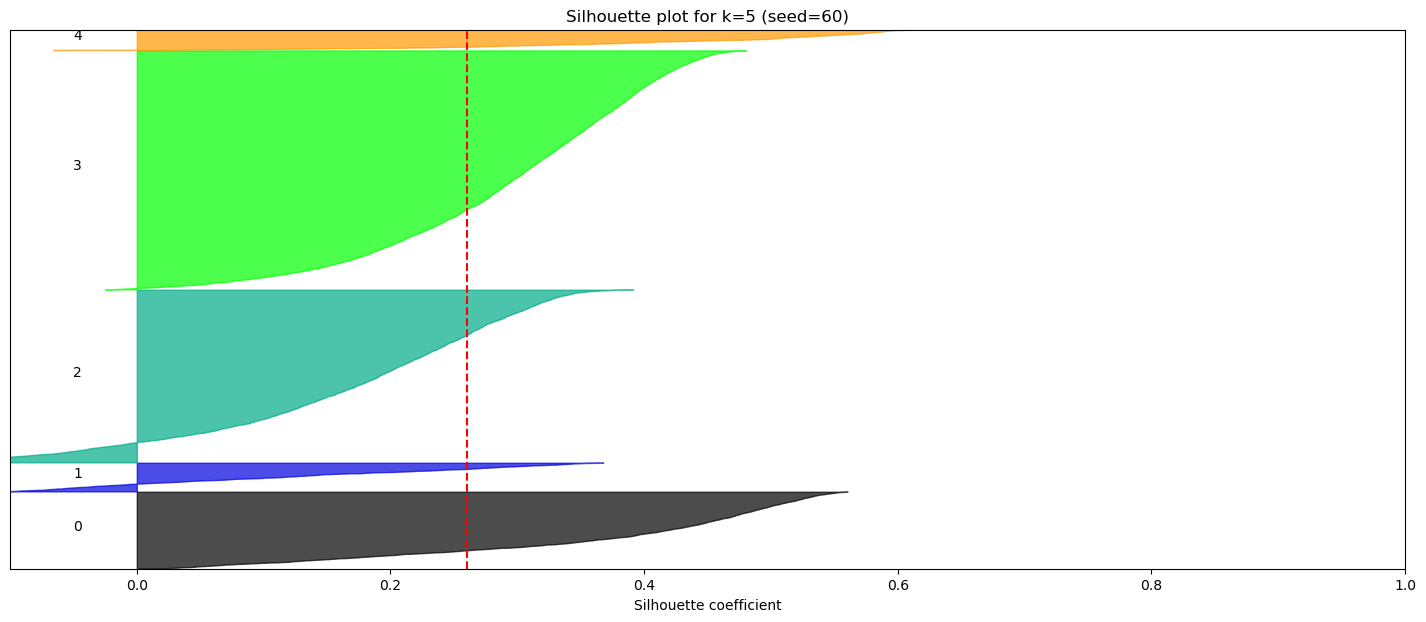

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

def plot_silhouette(X, k, seed):
    fig, ax1 = plt.subplots(1, 1, figsize=(18, 7))
    ax1.set_xlim([-0.1, 1.0])
    ax1.set_ylim([0, len(X) + k * 10])

    km = KMeans(n_clusters=k, random_state=seed, init='k-means++', n_init=10)
    labels = km.fit_predict(X)

    # chequeo de clusters vacíos
    uniq, counts = np.unique(labels, return_counts=True)
    if len(uniq) < k:
        print(f"⚠️ Con seed={seed} hay clusters vacíos: {dict(zip(uniq, counts))}")

    s_avg = silhouette_score(X, labels)
    s_vals = silhouette_samples(X, labels)

    y_lower = 10
    for i in range(k):
        vals_i = s_vals[labels == i]
        vals_i.sort()
        size_i = vals_i.shape[0]
        y_upper = y_lower + size_i

        color = cm.nipy_spectral(float(i) / max(k, 1))
        ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, vals_i,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ax1.text(-0.05, y_lower + 0.5 * size_i, str(i))
        y_lower = y_upper + 10

    ax1.axvline(x=s_avg, color="red", linestyle="--")
    ax1.set_title(f"Silhouette plot for k={k} (seed={seed})")
    ax1.set_xlabel("Silhouette coefficient")
    ax1.set_yticks([])
    plt.show()

# ejemplo de uso
# ahora también probamos con k=5
valores = [
    (9, 3),
    (22, 4),
    (33, 4),
    (42, 3),
    (50, 4),
    (60, 5)  
]

for seed, k in valores:
    plot_silhouette(scaled_df, k, seed)

Lo que podemos ver es que la silueta muestra clases más balanceadas con k=4, aunque la media del coeficiente entre clases baje un poco en comparación con k=3 podemos obtener un resultado más detallado con 4 clases puesto que no hay una clase dominante consumiendo los datos casi en su totalidad sino que se alcanzan a ver las diferentes clases un poco más balanceadas.

In [32]:
def plot_model(k, semilla):
    model = KMeans(n_clusters=k,random_state=semilla, init='random', n_init=1)
    model.fit(scaled_df)
    label = model.labels_

    pca = IncrementalPCA(n_components=2, whiten=True)
    x_plot = pca.fit_transform(scaled_df)

    colors = ['gold','red','blue','green']
    colors = dict(zip(range(k), colors))

    plt.scatter(x=x_plot[:,0], y=x_plot[:,1], c=[colors.get(x) for x in label])
    plt.title(f'Grupos para la semilla {semilla} con k={k}')

ValueError: 'c' argument must be a color, a sequence of colors, or a sequence of numbers, not ['gold', 'red', 'gold', 'gold', None, 'gold', None, 'red', 'blue', None, 'blue', None, 'gold', 'blue', None, 'gold', 'blue', 'green', None, 'red', None, 'red', 'red', None, 'blue', 'gold', None, None, None, 'blue', None, None, None, 'red', 'red', None, 'red', 'blue', 'gold', 'blue', None, 'red', None, None, 'gold', None, 'gold', None, None, 'red', 'red', None, None, 'gold', 'gold', None, 'green', 'gold', 'red', 'red', 'red', None, 'gold', None, None, None, 'red', 'gold', None, None, 'red', 'red', 'blue', 'gold', 'red', 'blue', 'red', 'red', None, 'blue', None, 'gold', None, None, 'red', 'green', 'red', 'red', None, 'blue', 'red', 'gold', 'blue', 'gold', None, None, 'red', 'red', 'red', 'blue', 'red', None, None, None, 'gold', 'red', None, 'green', None, 'blue', 'gold', None, None, None, 'blue', 'green', None, None, 'gold', None, 'blue', 'red', None, None, None, 'red', 'blue', 'blue', 'blue', '

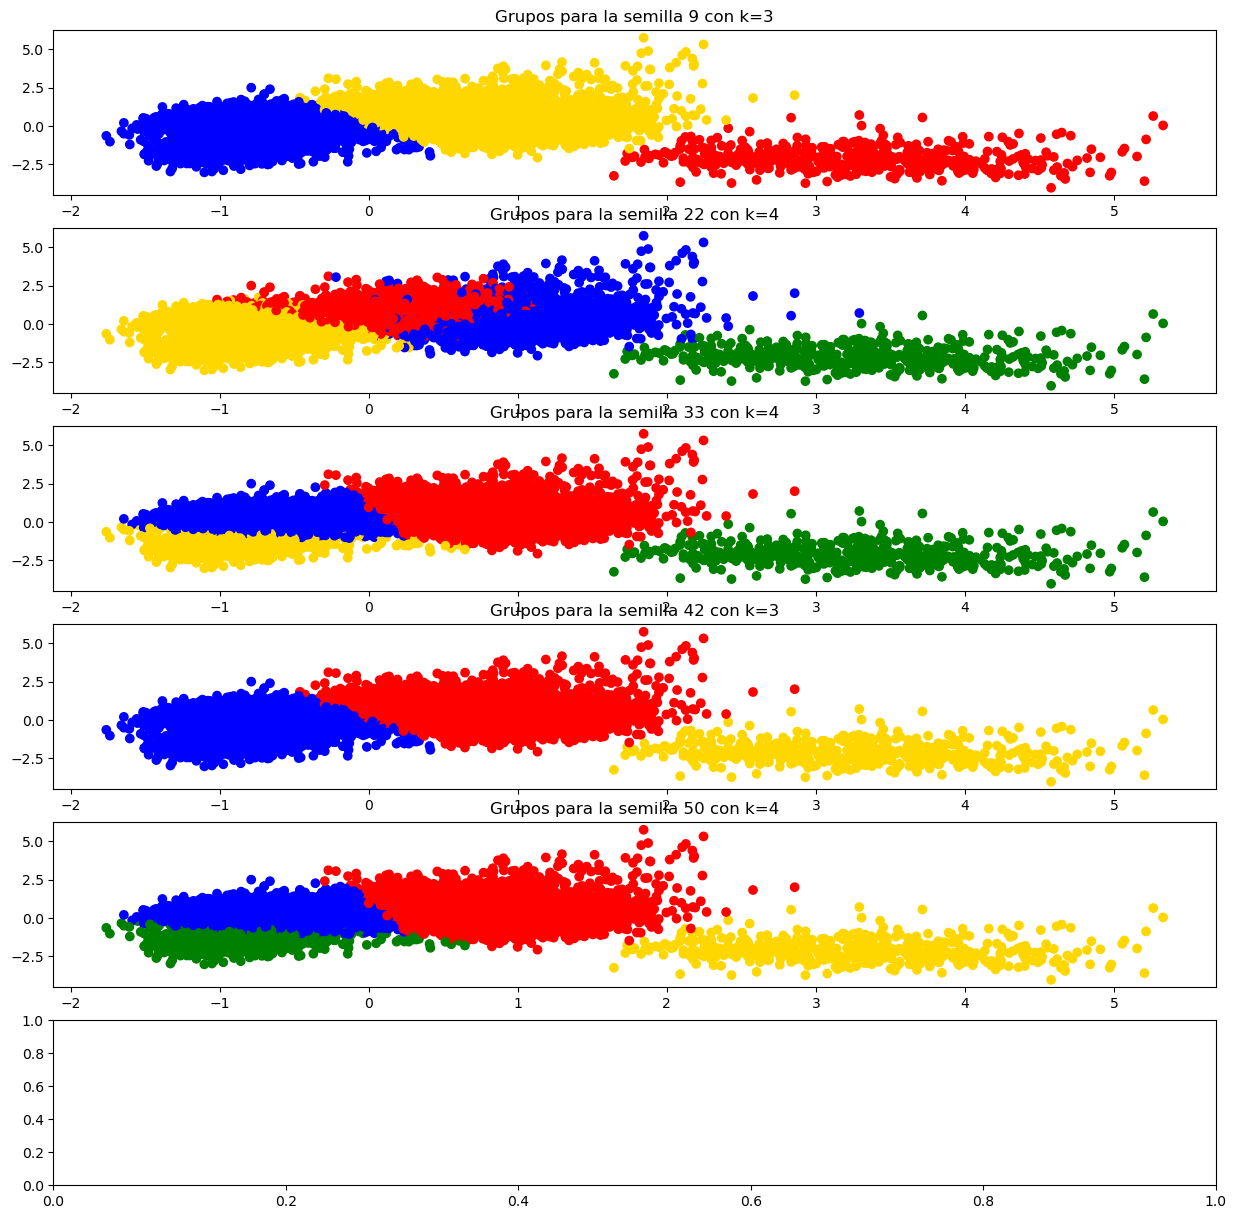

In [33]:
fig = plt.figure(figsize=(15, 15))

for i, valor in enumerate(valores):
    semilla, k = valor
    ax = plt.subplot(len(valores), 1, i + 1)
    plot_model(k, semilla)

plt.show()

Lo que podemos ver ahora en la visualización de los datos es que vamos a tener una nube de datos en donde van a encontrarse los granos de café principales y un conjunto de outliers agrupados.

## Algoritmo 2 (Martín Del Gordo)

### Gaussian Mixture Models (GMM)

El modelo Gaussian Mixture (GMM) asume que los datos provienen de una combinación de distribuciones gaussianas, cada una representando un cluster. A diferencia de K-Means, no obliga a que los clusters sean esféricos ni del mismo tamaño, y asigna probabilidades de pertenencia en lugar de etiquetas estrictas. Esto le da mayor flexibilidad para capturar la diversidad en la forma y tamaño de los granos de café.

Para la implementación se tomaron las siguientes decisiones sobre los hiperparámetros:
- Se evaluaron valores de k desde 2 hasta 10 para determinar el número de clusters más adecuado.
- Se utilizó el criterio BIC como métrica principal para seleccionar k, ya que equilibra ajuste y complejidad, penalizando el sobreajuste.
- Se configuró covariance_type="diag" para permitir varianzas distintas por dimensión sin calcular matrices completas, lo que reduce el costo computacional.
- Se estableció n_init=3 y max_iter=200 para mejorar la estabilidad de los resultados sin incrementar demasiado el tiempo de ejecución.
- Se calcularon métricas internas adicionales como el coeficiente de Silhouette, Calinski-Harabasz y Davies-Bouldin, que complementan la evaluación y ayudan a validar la calidad de los clusters obtenidos.

In [43]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import IncrementalPCA
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

k_values = [2, 3, 4, 5, 6, 7, 8, 9, 10]

resultados_gmm = []

for k in k_values:
    gmm = GaussianMixture(n_components=k, covariance_type="diag", n_init=3, max_iter=200, random_state=42)
    gmm.fit(scaled_df)
    labels = gmm.predict(scaled_df)
    
    bic = gmm.bic(scaled_df)
    aic = gmm.aic(scaled_df)
    
    if len(np.unique(labels)) > 1:
        sil = silhouette_score(scaled_df, labels)
        ch = calinski_harabasz_score(scaled_df, labels)
        db = davies_bouldin_score(scaled_df, labels)
    else:
        sil, ch, db = np.nan, np.nan, np.nan
    
    resultados_gmm.append({
        "k": k, "BIC": bic, "AIC": aic,
        "Silhouette": sil, "CalinskiHarabasz": ch, "DaviesBouldin": db
    })

res_gmm = pd.DataFrame(resultados_gmm)
display(res_gmm)

best_k = int(res_gmm.loc[res_gmm["BIC"].idxmin(), "k"])
print("Mejor k por BIC:", best_k)

best_gmm = GaussianMixture(n_components=best_k, covariance_type="diag", n_init=3, max_iter=200, random_state=42).fit(scaled_df)
best_labels = best_gmm.predict(scaled_df)


,k,BIC,AIC,Silhouette,CalinskiHarabasz,DaviesBouldin
0,2,25892.788532,25162.417935,0.153544,1595.008285,1.661947
1,3,-43473.970090,-44573.290783,0.209224,2272.756932,1.546832
2,4,-62537.471347,-64005.742135,0.195174,1908.864233,1.574055
3,5,-198838.770960,-200675.991843,0.227227,3743.610216,1.901673
4,6,-226283.195012,-228489.365990,0.231821,3555.928414,1.947192
5,7,-257439.248423,-260014.369497,0.161180,3223.608046,2.194699
6,8,-601214.574675,-604158.645844,0.114397,1866.786118,2.719599
7,9,-519560.819378,-522873.840643,0.016721,1638.673692,2.351047
8,10,-583660.324514,-587342.295874,0.057853,1556.146566,2.224063


Mejor k por BIC: 8


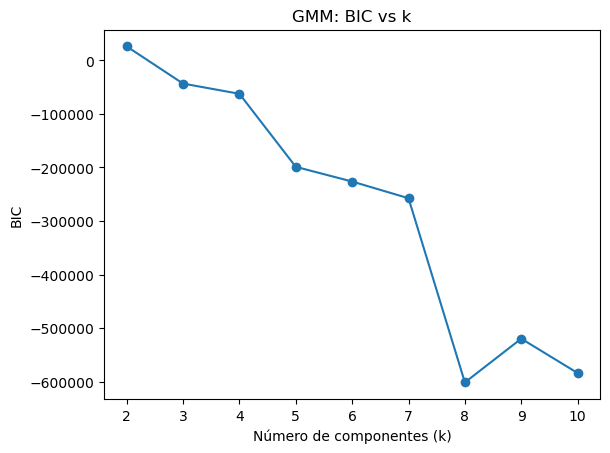

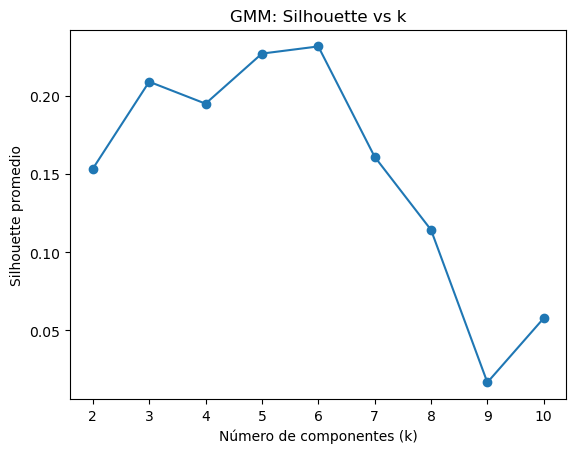

In [44]:
plt.figure()
plt.plot(res_gmm["k"], res_gmm["BIC"], marker="o")
plt.xlabel("Número de componentes (k)")
plt.ylabel("BIC")
plt.title("GMM: BIC vs k")
plt.show()

plt.figure()
plt.plot(res_gmm["k"], res_gmm["Silhouette"], marker="o")
plt.xlabel("Número de componentes (k)")
plt.ylabel("Silhouette promedio")
plt.title("GMM: Silhouette vs k")
plt.show()

En la gráfica de BIC vs k  se muestra cómo el BIC disminuye de manera continua al aumentar el número de componentes y alcanza su valor más bajo en k=8.  

Por otro lado, en la gráfica de Silhouette vs k se ve que el coeficiente de Silhouette promedio alcanza su máximo en k=6, con un valor cercano a 0.23. A partir de k=7 la métrica cae de forma considerable.Esto indica que la mejor separación y cohesión de los clusters se da alrededor de k=6.  

El BIC favorece k=8 como mejor ajuste estadístico, mientras que el Silhouette señala que k=6 ofrece grupos más compactos y separados. En términos prácticos, k=6 puede ser una opción más interpretable para control de calidad, mientras que k=8 captura con mayor detalle la estructura probabilística de los datos.


En este caso se decidió trabajar con k=8, ya que permite capturar una estructura más detallada de los datos. Aunque k=6 ofrece grupos más compactos, k=8 aporta una visión más rica de la diversidad  de los granos, lo que resulta valioso para SenecaféAlpes al mejorar el control de calidad, diseñar mezclas diferenciadas y fortalecer la trazabilidad de sus procesos.

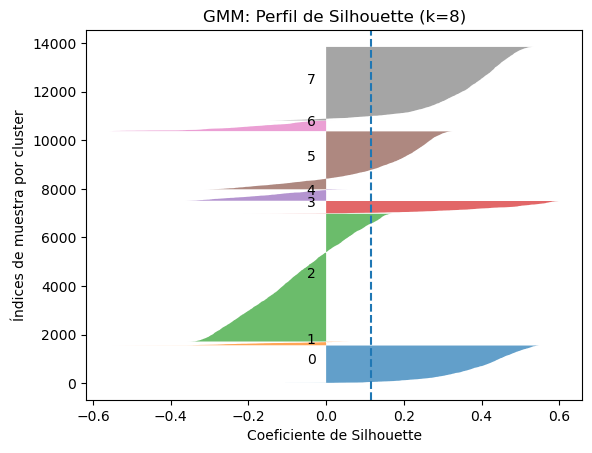

In [45]:
sample_sil = silhouette_samples(scaled_df, best_labels)
y_lower = 10
plt.figure()
for c in range(best_k):
    c_sil = sample_sil[best_labels == c]
    c_sil.sort()
    size = c_sil.shape[0]
    y_upper = y_lower + size
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, c_sil, alpha=0.7)
    plt.text(-0.05, y_lower + 0.5*size, str(c))
    y_lower = y_upper + 10
plt.axvline(x=np.mean(sample_sil), linestyle="--")
plt.xlabel("Coeficiente de Silhouette")
plt.ylabel("Índices de muestra por cluster")
plt.title(f"GMM: Perfil de Silhouette (k={best_k})")
plt.show()


El perfil de Silhouette con k=8 muestra una calidad global moderada (~0.2). Algunos clusters están bien definidos y compactos, mientras que otros presentan solapamiento y dispersión. Esto indica que el modelo captura tanto diferencias claras como similitudes entre las variedades de café.

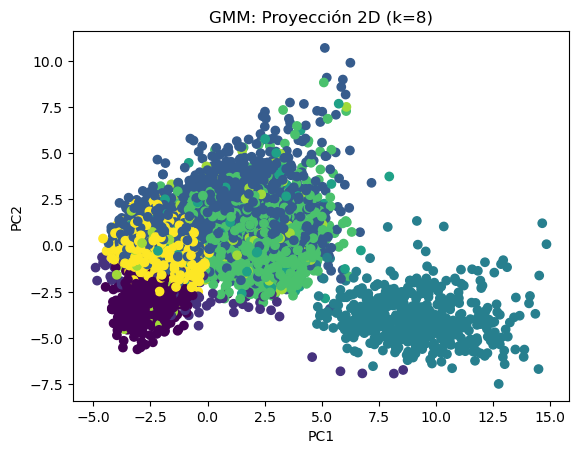

In [47]:
pca = IncrementalPCA(n_components=2)
X_2d = pca.fit_transform(scaled_df)

plt.figure()
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=best_labels)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"GMM: Proyección 2D (k={best_k})")
plt.show()

La proyección en 2D muestra ocho clusters, algunos bien separados y otros con solapamiento. Esto indica que existen grupos de granos con patrones claros y otros con características más similares entre sí.

Conclusión:  
El modelo GMM con k=8 logra representar de manera más completa la estructura de los datos, mostrando clusters claramente definidos junto con otros que presentan cierto solapamiento. Esta clasificación evidencia la variedad morfológica de los granos de café y permite a SenecaféAlpes mejorar sus procesos de control de calidad, aprovechar la diversidad en el diseño de nuevas mezclas y avanzar hacia sistemas de trazabilidad más precisos.

## Algoritmo 3